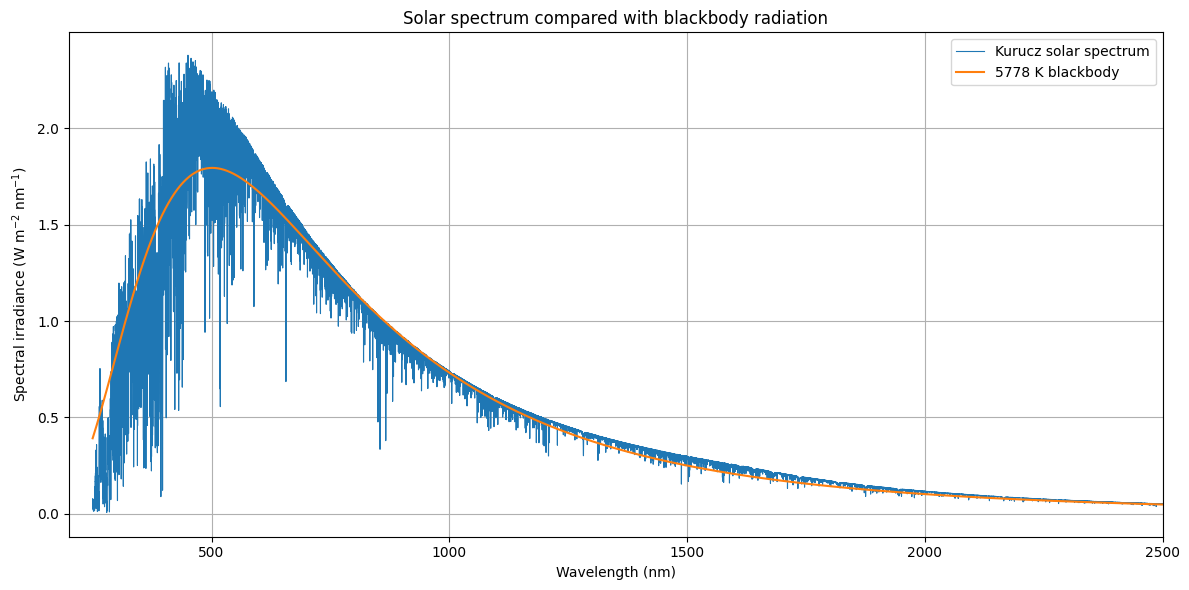

Calculated solar constant: 1365.77 W/m²


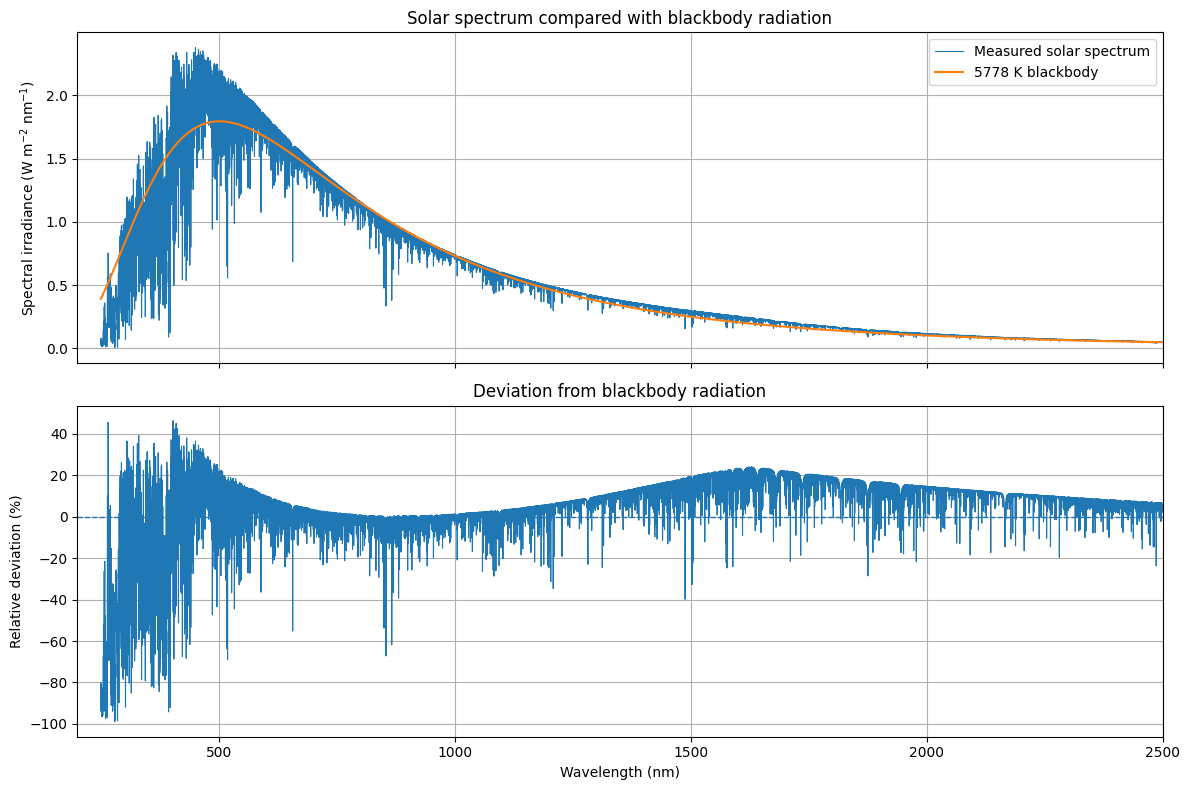

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
h = 6.62607015e-34       # Planck constant (J s)
c = 2.99792458e8         # Speed of light (m/s)
k_B = 1.380649e-23       # Boltzmann constant (J/K)
R_sun = 696340           # Radius of the Sun (km)
R_earth = 149600000      # Mean Earth-Sun distance (km)

# Temperature of the Sun
T_sun = 5778             # K

# Load solar spectrum
data = np.loadtxt("kurudz_0.1nm.dat")

wavelength = data[:, 0]  # nm
irradiance = data[:, 1]  # mW m^-2 nm^-1

# Convert irradiance to W m^-2 nm^-1
irradiance = irradiance * 1e-3

# Calculate blackbody spectral radiance
def blackbody(wavelength, T):
    wavelength_m = wavelength * 1e-9

    B = (2 * h * c**2 / wavelength_m**5) / (
        np.exp(h * c / (wavelength_m * k_B * T)) - 1
    )

    return B

# Calculate solar spectral irradiance at Earth
def blackbody_sun(wavelength, T):
    B = blackbody(wavelength, T)

    return np.pi * B * (R_sun / R_earth)**2 * 1e-9

# Calculate blackbody spectrum
blackbody_irradiance = blackbody_sun(wavelength, T_sun)

# Plot both spectra
plt.figure(figsize=(12, 6))

plt.plot(
    wavelength,
    irradiance,
    label="Kurucz solar spectrum",
    linewidth=0.8
)

plt.plot(
    wavelength,
    blackbody_irradiance,
    label="5778 K blackbody",
    linewidth=1.5
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral irradiance (W m$^{-2}$ nm$^{-1}$)")
plt.title("Solar spectrum compared with blackbody radiation")

plt.xlim(200, 2500)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Calculate solar constant
solar_constant = np.trapezoid(irradiance, wavelength)

print(f"Calculated solar constant: {solar_constant:.2f} W/m²")


# Calculate absolute and relative deviations
absolute_deviation = irradiance - blackbody_irradiance

relative_deviation = (
    absolute_deviation / blackbody_irradiance
) * 100

# Exclude wavelengths where the blackbody irradiance is very small
valid = blackbody_irradiance > 0.01 * np.max(blackbody_irradiance)

# Create two subplots
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True
)

# Top plot: Solar spectrum and blackbody spectrum
ax1.plot(
    wavelength, irradiance,
    label="Measured solar spectrum",
    linewidth=0.8
)

ax1.plot(
    wavelength, blackbody_irradiance,
    label="5778 K blackbody",
    linewidth=1.5
)

ax1.set_ylabel("Spectral irradiance (W m$^{-2}$ nm$^{-1}$)")
ax1.set_title("Solar spectrum compared with blackbody radiation")
ax1.legend()
ax1.grid(True)

# Bottom plot: Relative deviation
ax2.plot(
    wavelength[valid],
    relative_deviation[valid],
    linewidth=0.8
)

ax2.axhline(0, linestyle="--", linewidth=1)

ax2.set_xlabel("Wavelength (nm)")
ax2.set_ylabel("Relative deviation (%)")
ax2.set_title("Deviation from blackbody radiation")
ax2.grid(True)

ax2.set_xlim(200, 2500)

plt.tight_layout()
plt.show()



